In [5]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 5.4 MB/s eta 0:00:02
   ------------------------------------ --- 7.3/8.1 MB 24.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 23.8 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [sci


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. เตรียมข้อมูลสมมติ (X = ขนาดพื้นที่บ้าน ตร.ม., y = ราคาบ้าน ล้านบาท)
# สมมติว่าราคามีความสัมพันธ์แปรผันตรงกับพื้นที่
np.random.seed(42)
X = np.random.rand(100, 1) * 100  # พื้นที่ 0 - 100 ตร.ม.
y = 2.5 * X + np.random.randn(100, 1) * 20  # สูตรสมมติ: ราคา = 2.5*(พื้นที่) + ความเพี้ยน (noise)

# 2. แบ่งข้อมูลเป็น Train (สำหรับเรียนรู้) และ Test (สำหรับประเมินผล)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. สร้าง Model และเทรนข้อมูล (Fit)
model = LinearRegression()
model.fit(X_train, y_train)

# 4. นำโมเดลไปพยากรณ์ข้อมูล Test
y_pred = model.predict(X_test)

# 5. วัดผลลัพธ์
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"ค่าความชัน (Slope/Coefficient): {model.coef_[0][0]:.2f}")
print(f"จุดตัดแกน Y (Intercept): {model.intercept_[0]:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (ความแม่นยำ): {r2:.2f}")

ค่าความชัน (Slope/Coefficient): 2.42
จุดตัดแกน Y (Intercept): 2.86
Mean Squared Error (MSE): 261.48
R-squared Score (ความแม่นยำ): 0.95


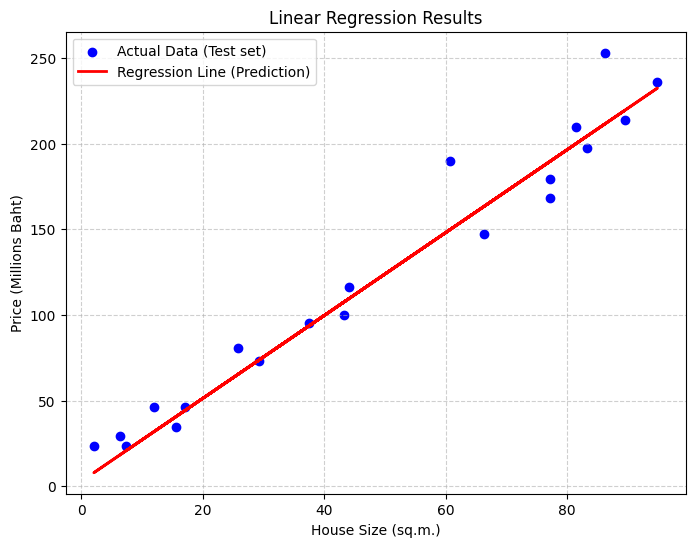

In [8]:
# 6. พล็อตกราฟแสดงผล
plt.figure(figsize=(8, 6))

# พล็อตข้อมูลทดสอบจริง (Actual Data) เป็นจุดสีน้ำเงิน
plt.scatter(X_test, y_test, color='blue', label='Actual Data (Test set)')

# พล็อตเส้นตรงที่โมเดลพยากรณ์ (Regression Line) เป็นเส้นสีแดง
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line (Prediction)')

# ใส่ชื่อกราฟและคำอธิบายแกน
plt.title('Linear Regression Results')
plt.xlabel('House Size (sq.m.)')
plt.ylabel('Price (Millions Baht)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# แสดงกราฟ
plt.show()